In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
import numpy as np

In [2]:
# Physical constants
mu_B = 5.788e-5    # Bohr magneton in eV/T
eV_to_cm = 8065.54 # 1 eV = 8065.54 cm^-1
R_H = 109677.58    # Rydberg constant for hydrogen in cm^-1
mu_B_cm = mu_B * eV_to_cm  # Bohr magneton in cm^-1/T (~0.4669 cm^-1/T)

def bohr_energies(n, B):
    """
    Bohr model energies with magnetic field correction (in cm^-1).
    
    In the Bohr model the electron orbits in a circle with L = n*hbar.
    The only physical orientations are m = +n (orbit "up") and m = -n
    (orbit "down"). There is no m = 0 state — that would require
    zero angular momentum, which doesn't exist in the Bohr model.
    
    E(n, m) = -R_H/n^2 + m * mu_B * B    where m = +n or -n
    
    Parameters
    ----------
    n : int
        Principal quantum number
    B : float
        Magnetic field strength in Tesla
    
    Returns
    -------
    list of (m, E) tuples, energies in cm^-1
    """
    E_n = -R_H / n**2
    states = []
    for m in [+n, -n]:
        E = E_n + m * mu_B_cm * B
        states.append((m, E))
    return states

def hydrogen_energies(n, B):
    """
    QM hydrogen atom energies with magnetic field correction (in cm^-1).
    
    E(n, l, m_l) = -R_H/n^2 + m_l * mu_B * B
    
    l ranges from 0 to n-1, m_l from -l to +l.
    Spin is ignored.
    
    Parameters
    ----------
    n : int
        Principal quantum number
    B : float
        Magnetic field strength in Tesla
    
    Returns
    -------
    list of (l, m_l, E) tuples, energies in cm^-1
    """
    E_n = -R_H / n**2
    states = []
    for l in range(n):
        for m_l in range(-l, l + 1):
            E = E_n + m_l * mu_B_cm * B
            states.append((l, m_l, E))
    return states

# Sanity check
print(f"mu_B in cm^-1/T: {mu_B_cm:.4f}")
print(f"Ly-alpha at B=0: {R_H * (1 - 1/4):.1f} cm^-1")
print()
print("Bohr n=1, B=4T:", bohr_energies(1, 4.0))
print("Bohr n=2, B=4T:", bohr_energies(2, 4.0))
print()
print("QM   n=2, B=4T:", hydrogen_energies(2, 4.0))

mu_B in cm^-1/T: 0.4668
Ly-alpha at B=0: 82258.2 cm^-1

Bohr n=1, B=4T: [(1, -109675.7126661792), (-1, -109679.4473338208)]
Bohr n=2, B=4T: [(2, -27415.660332358402), (-2, -27423.1296676416)]

QM   n=2, B=4T: [(0, 0, -27419.395), (1, -1, -27421.2623338208), (1, 0, -27419.395), (1, 1, -27417.5276661792)]


In [3]:
def bohr_lyman_transitions(n_upper, B):
    """
    Lyman series transitions n_upper -> 1 using the Bohr model.
    
    No selection rules — all m_upper -> m_lower transitions are allowed.
    Each level has only m = +n and m = -n.
    
    For 2 -> 1 this gives 4 transitions:
        (+2) -> (+1), (+2) -> (-1), (-2) -> (+1), (-2) -> (-1)
    
    Returns list of transition wavenumbers in cm^-1.
    """
    upper_states = bohr_energies(n_upper, B)
    lower_states = bohr_energies(1, B)
    
    wavenumbers = []
    for m_u, E_u in upper_states:
        for m_l, E_l in lower_states:
            dE = E_u - E_l
            wavenumbers.append(abs(dE))
    return sorted(set(round(w, 4) for w in wavenumbers))

def qm_lyman_transitions(n_upper, B):
    """
    Lyman series transitions n_upper -> 1 using QM hydrogen model.
    
    Selection rules (no spin): Delta_l = +/-1, Delta_m_l = 0, +/-1.
    Lower state is n=1, l=0, m_l=0 only.
    So upper state must have l=1, m_l in {-1, 0, +1}.
    
    Returns list of transition wavenumbers in cm^-1.
    """
    upper_states = hydrogen_energies(n_upper, B)
    lower_states = hydrogen_energies(1, B)  # only (l=0, m_l=0)
    
    wavenumbers = []
    for l_u, ml_u, E_u in upper_states:
        for l_l, ml_l, E_l in lower_states:
            if abs(l_u - l_l) == 1 and abs(ml_u - ml_l) <= 1:
                dE = E_u - E_l
                wavenumbers.append(abs(dE))
    return sorted(set(round(w, 4) for w in wavenumbers))

# Test: Lyman-alpha
print("Bohr  Ly-alpha B=0:", bohr_lyman_transitions(2, 0))
print("QM    Ly-alpha B=0:", qm_lyman_transitions(2, 0))
print()
print(f"Bohr  Ly-alpha B=4: {len(bohr_lyman_transitions(2, 4))} lines", bohr_lyman_transitions(2, 4))
print(f"QM    Ly-alpha B=4: {len(qm_lyman_transitions(2, 4))} lines", qm_lyman_transitions(2, 4))

Bohr  Ly-alpha B=0: [82258.185]
QM    Ly-alpha B=0: [82258.185]

Bohr  Ly-alpha B=4: 4 lines [82252.583, 82256.3177, 82260.0523, 82263.787]
QM    Ly-alpha B=4: 3 lines [82256.3177, 82258.185, 82260.0523]


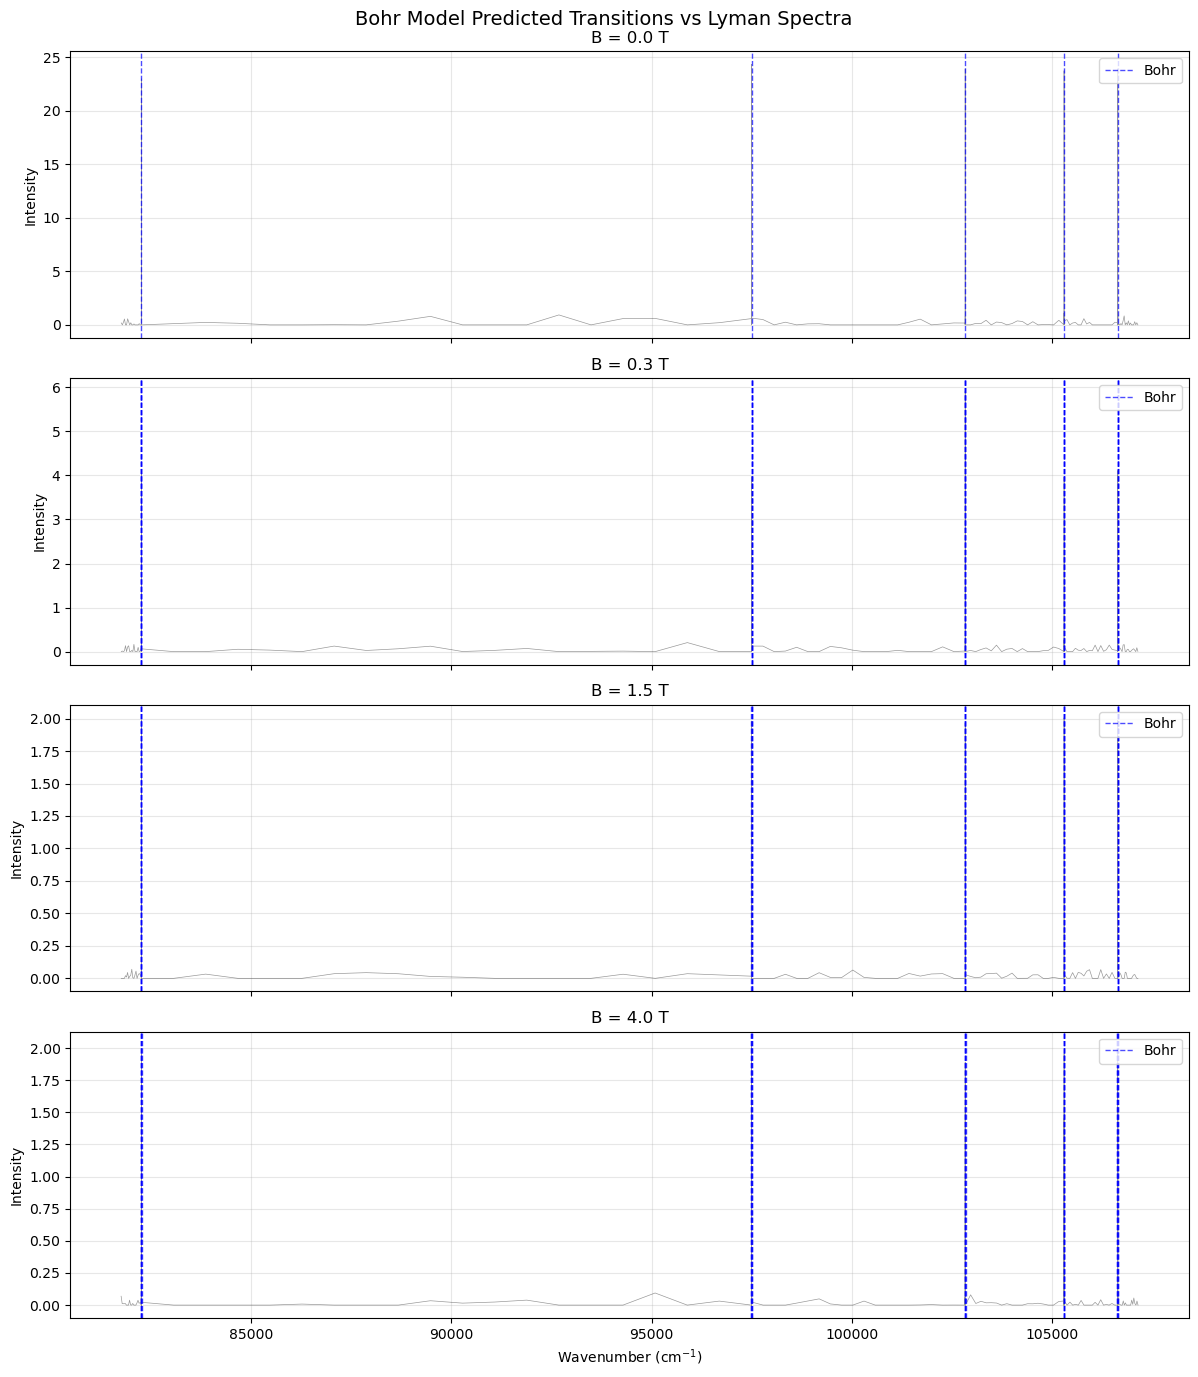

In [4]:
# Map data files to magnetic field strengths (Tesla)
field_map = {
    'lyman_B0.csv':  0.0,
    'lyman_B03.csv': 0.3,
    'lyman_B15.csv': 1.5,
    'lyman_B4.csv':  4.0,
}
fields_sorted = sorted(field_map.items(), key=lambda x: x[1])
n_upper_values = [2, 3, 4, 5, 6]

# --- Full spectrum: Bohr model vs spectra ---
fig, axes = plt.subplots(len(field_map), 1, figsize=(12, 3.5 * len(field_map)), sharex=True)

for ax, (filename, B) in zip(axes, fields_sorted):
    data = pd.read_csv(f"data/{filename}")
    ax.plot(data['wavenumber_cm-1'], data['intensity'], 'k-', alpha=0.4, linewidth=0.5)
    
    bohr_lines = []
    for n in n_upper_values:
        bohr_lines.extend(bohr_lyman_transitions(n, B))
    for i, wn in enumerate(bohr_lines):
        ax.axvline(wn, color='blue', alpha=0.7, linestyle='--', linewidth=1,
                   label='Bohr' if i == 0 else '')
    
    ax.set_ylabel('Intensity')
    ax.set_title(f'B = {B} T')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Wavenumber (cm$^{-1}$)')
fig.suptitle('Bohr Model Predicted Transitions vs Lyman Spectra', fontsize=14)
plt.tight_layout()
plt.show()

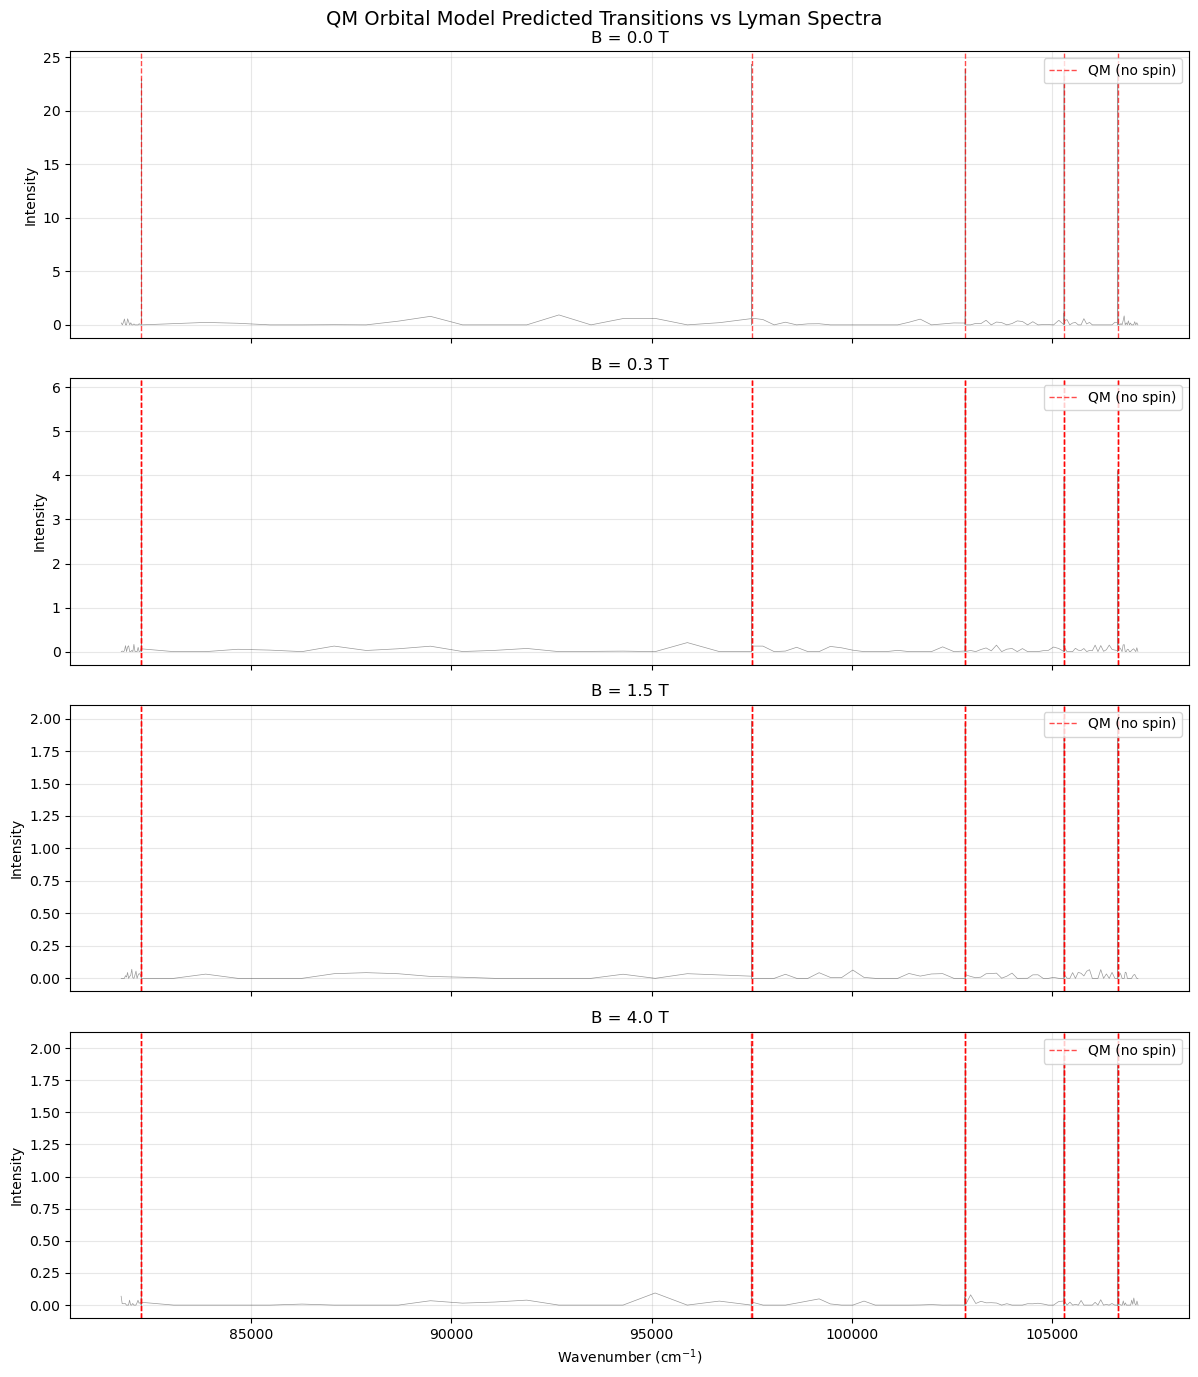

In [5]:
# --- Full spectrum: QM orbital model vs spectra ---
fig, axes = plt.subplots(len(field_map), 1, figsize=(12, 3.5 * len(field_map)), sharex=True)

for ax, (filename, B) in zip(axes, fields_sorted):
    data = pd.read_csv(f"data/{filename}")
    ax.plot(data['wavenumber_cm-1'], data['intensity'], 'k-', alpha=0.4, linewidth=0.5)
    
    qm_lines = []
    for n in n_upper_values:
        qm_lines.extend(qm_lyman_transitions(n, B))
    for i, wn in enumerate(qm_lines):
        ax.axvline(wn, color='red', alpha=0.7, linestyle='--', linewidth=1,
                   label='QM (no spin)' if i == 0 else '')
    
    ax.set_ylabel('Intensity')
    ax.set_title(f'B = {B} T')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Wavenumber (cm$^{-1}$)')
fig.suptitle('QM Orbital Model Predicted Transitions vs Lyman Spectra', fontsize=14)
plt.tight_layout()
plt.show()

## Zoomed In: Lyman-alpha Splitting

Zoom into the first Lyman peak (n=2 → 1) to see how the magnetic field splits it, and compare the Bohr and QM model predictions side by side.

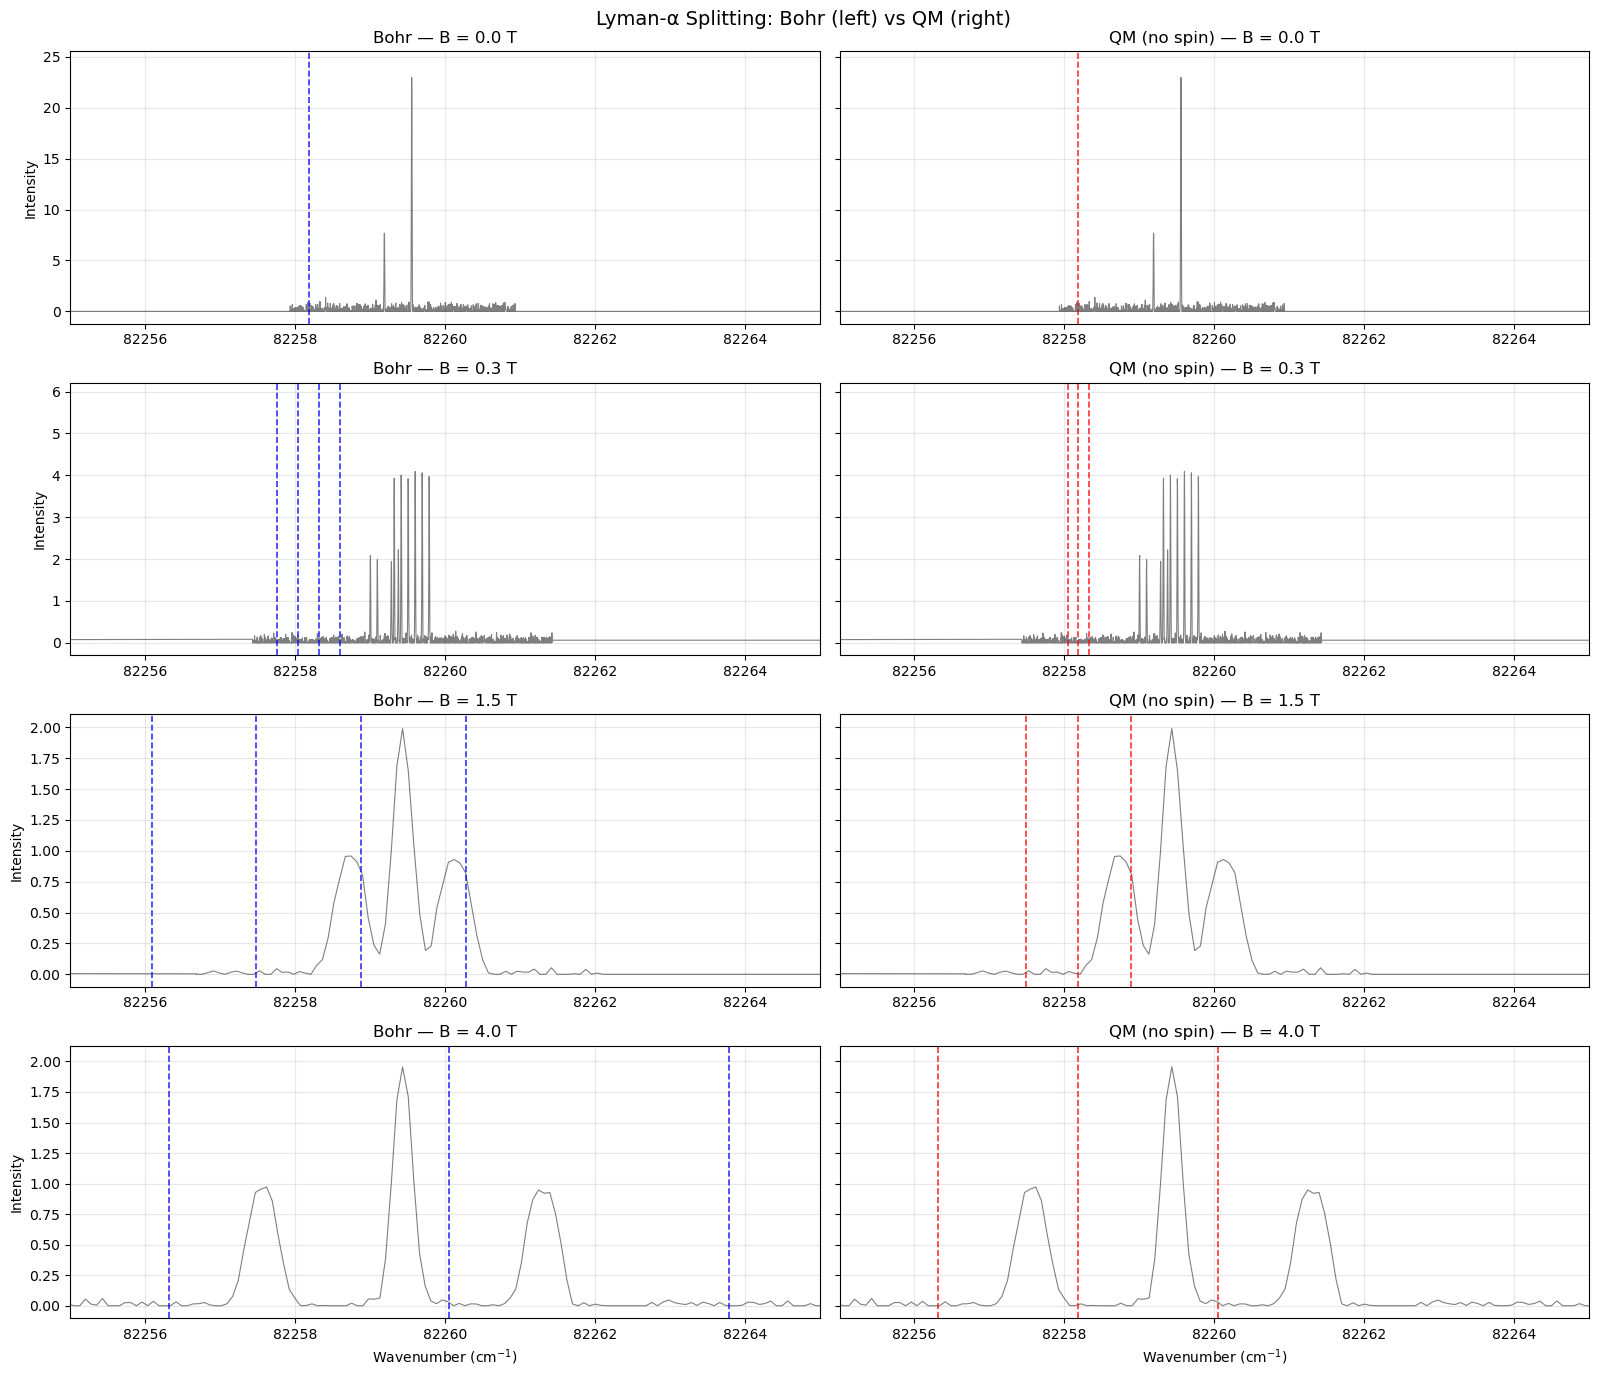

In [6]:
# Zoomed view: Lyman-alpha region, Bohr vs QM side by side
fig, axes = plt.subplots(len(field_map), 2, figsize=(16, 3.5 * len(field_map)),
                         sharey='row')

for row, (filename, B) in enumerate(fields_sorted):
    data = pd.read_csv(f"data/{filename}")
    
    # --- Left panel: Bohr model ---
    ax_b = axes[row, 0]
    ax_b.plot(data['wavenumber_cm-1'], data['intensity'], 'k-', alpha=0.5, linewidth=0.8)
    for wn in bohr_lyman_transitions(2, B):
        ax_b.axvline(wn, color='blue', alpha=0.8, linestyle='--', linewidth=1.2)
    ax_b.set_xlim(82255, 82265)
    ax_b.set_ylabel('Intensity')
    ax_b.set_title(f'Bohr — B = {B} T')
    ax_b.grid(alpha=0.3)
    
    # --- Right panel: QM model ---
    ax_q = axes[row, 1]
    ax_q.plot(data['wavenumber_cm-1'], data['intensity'], 'k-', alpha=0.5, linewidth=0.8)
    for wn in qm_lyman_transitions(2, B):
        ax_q.axvline(wn, color='red', alpha=0.8, linestyle='--', linewidth=1.2)
    ax_q.set_xlim(82255, 82265)
    ax_q.set_title(f'QM (no spin) — B = {B} T')
    ax_q.grid(alpha=0.3)

axes[-1, 0].set_xlabel('Wavenumber (cm$^{-1}$)')
axes[-1, 1].set_xlabel('Wavenumber (cm$^{-1}$)')
fig.suptitle('Lyman-α Splitting: Bohr (left) vs QM (right)', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
data = pd.read_csv(f"data/lyman_B0.csv")
print(data)
plot_spectrum(data, "lyman B0")

data_filtered = data[data['wavenumber_cm-1'] <= 83060]
plot_spectrum(data_filtered, "no field")

      wavenumber_cm-1  intensity
0        81757.934436   0.178560
1        81784.250225   0.000000
2        81810.566015   0.232832
3        81836.881804   0.547502
4        81863.197594   0.000000
...               ...        ...
6115    107028.665788   0.000000
6116    107054.981577   0.295620
6117    107081.297367   0.000000
6118    107107.613156   0.198421
6119    107133.928946   0.000000

[6120 rows x 2 columns]


NameError: name 'plot_spectrum' is not defined

lyman_B0.csv
      wavenumber_cm-1  intensity
0        81757.934436   0.178560
1        81784.250225   0.000000
2        81810.566015   0.232832
3        81836.881804   0.547502
4        81863.197594   0.000000
...               ...        ...
6115    107028.665788   0.000000
6116    107054.981577   0.295620
6117    107081.297367   0.000000
6118    107107.613156   0.198421
6119    107133.928946   0.000000

[6120 rows x 2 columns]


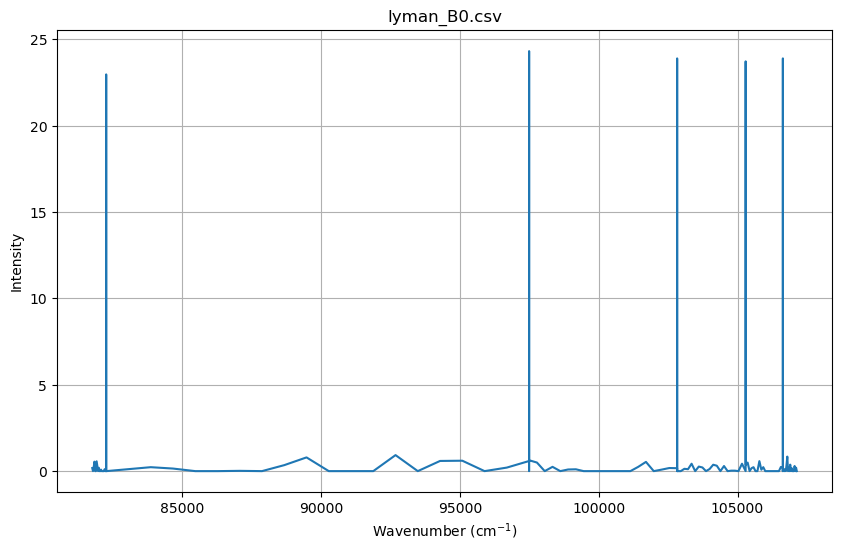

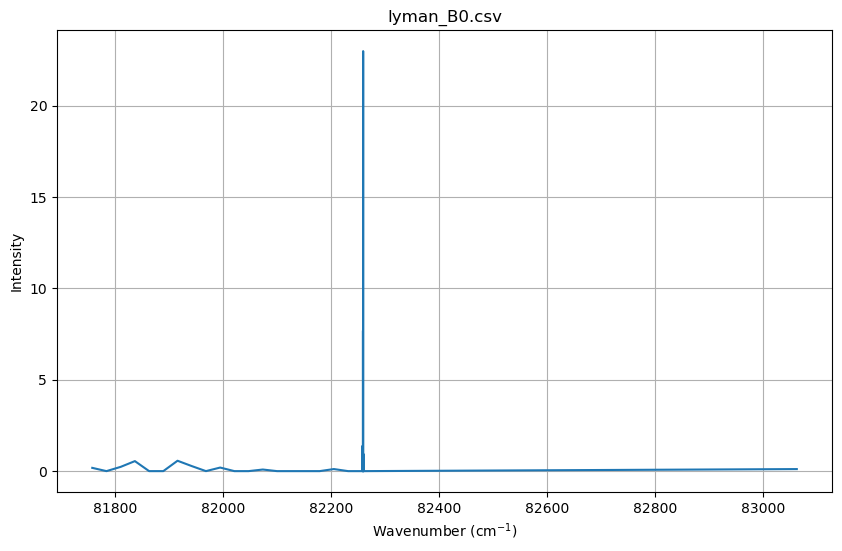

lyman_B03.csv
      wavenumber_cm-1  intensity
0        81757.434436   0.000000
1        81783.750225   0.013045
2        81810.066015   0.000000
3        81836.381804   0.018573
4        81862.697594   0.135112
...               ...        ...
8115    107029.165788   0.064082
8116    107055.481577   0.030839
8117    107081.797367   0.000000
8118    107108.113156   0.087760
8119    107134.428946   0.005814

[8120 rows x 2 columns]


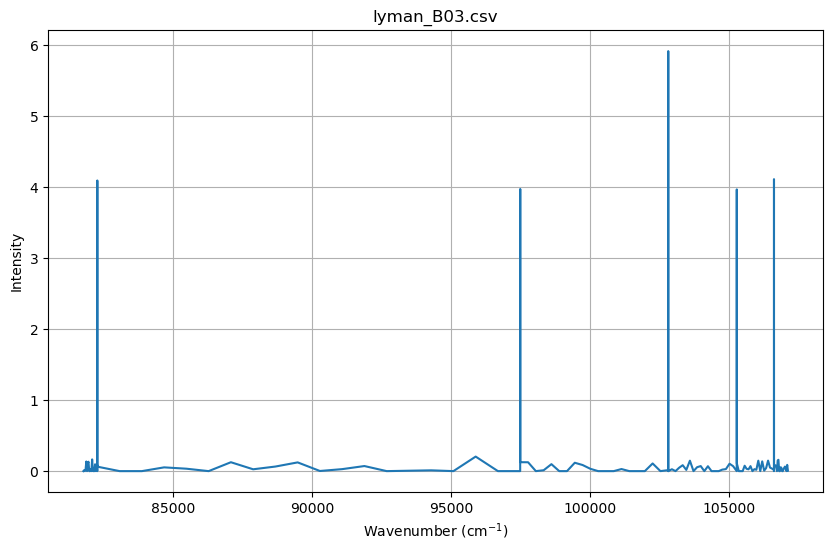

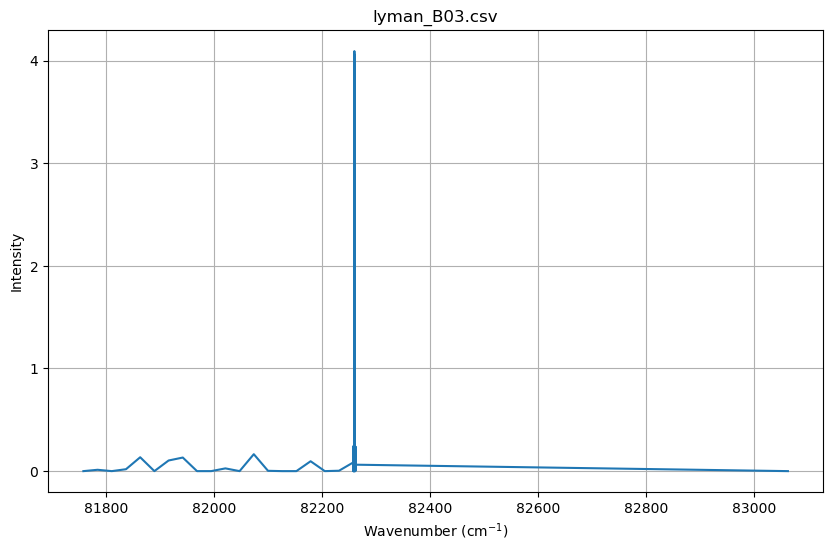

lyman_B15.csv
       wavenumber_cm-1  intensity
0         81756.683711   0.000000
1         81782.999500   0.000000
2         81809.315290   0.000000
3         81835.631079   0.000000
4         81861.946869   0.009888
...                ...        ...
11115    107029.916513   0.000000
11116    107056.232302   0.000000
11117    107082.548092   0.000000
11118    107108.863881   0.000000
11119    107135.179671   0.000000

[11120 rows x 2 columns]


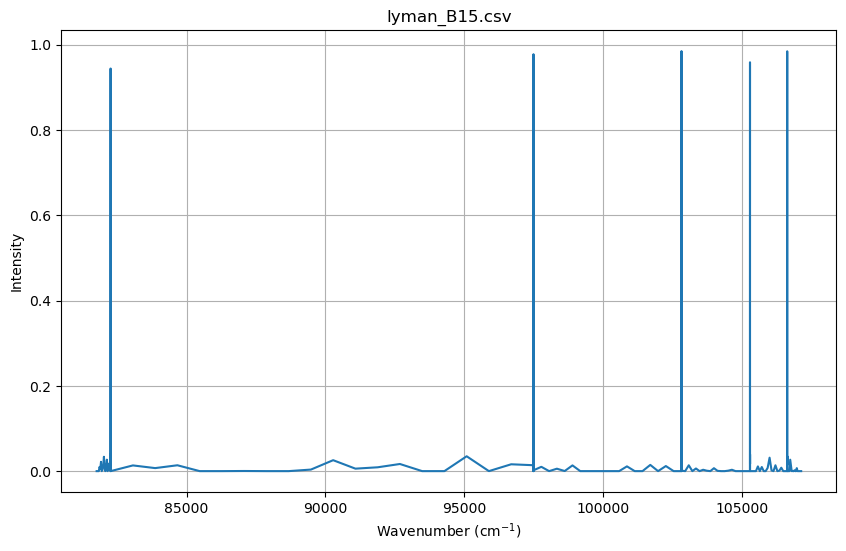

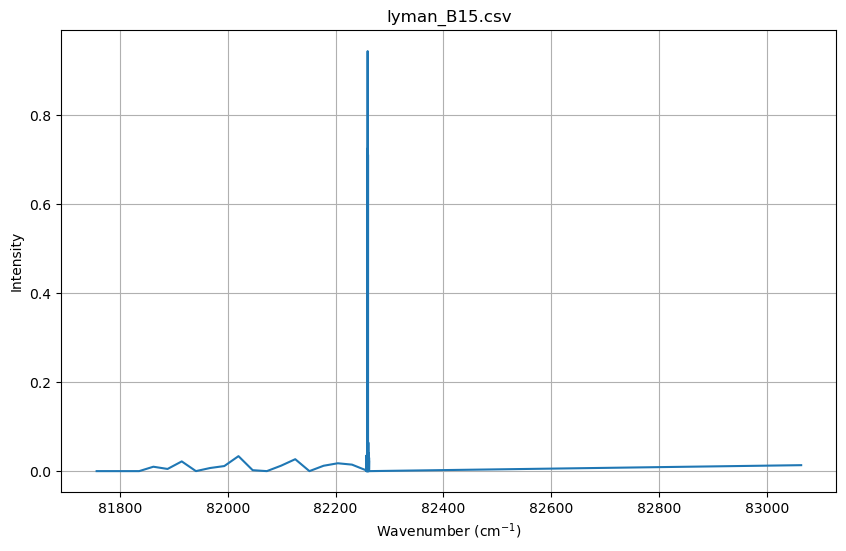

lyman_B4.csv
       wavenumber_cm-1  intensity
0         81753.765836   0.016216
1         81780.081625   0.000000
2         81806.397415   0.000000
3         81832.713204   0.000000
4         81859.028994   0.000000
...                ...        ...
22785    107032.834388   0.017112
22786    107059.150177   0.008085
22787    107085.465967   0.023797
22788    107111.781756   0.000000
22789    107138.097546   0.000000

[22790 rows x 2 columns]


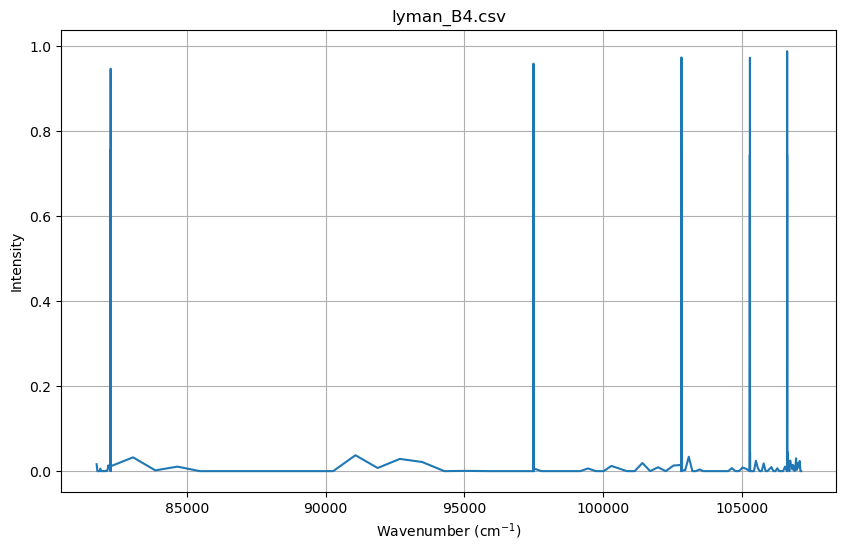

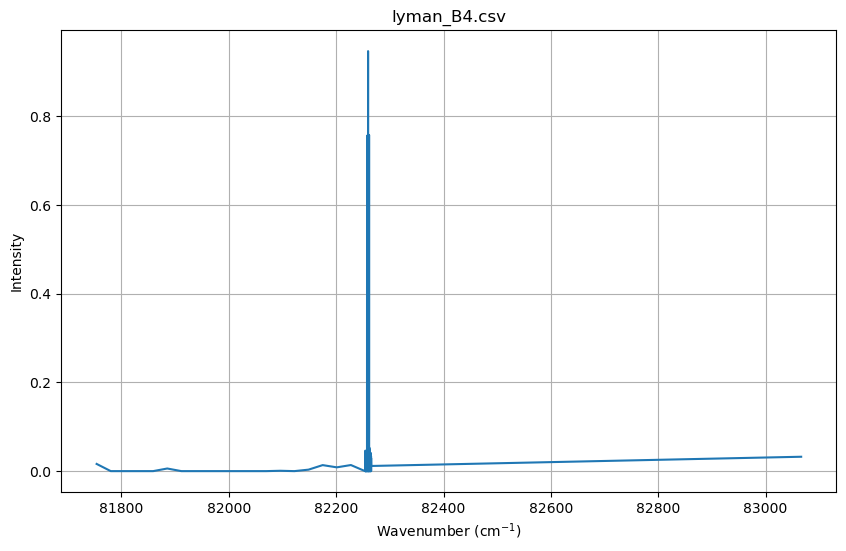

In [ ]:
import os
def plot_spectrum(data, title):
    plt.figure(figsize=(10, 6))
    plt.plot(data['wavenumber_cm-1'], data['intensity'])
    plt.title(title)
    plt.xlabel('Wavenumber (cm$^{-1}$)')
    plt.ylabel('Intensity')
    plt.grid()
    plt.show()
   
   
    
for file in os.listdir("data"):
    data = pd.read_csv(f"data/{file}")
    print(file)
    print(data)
    plot_spectrum(data, file)
    
    data_filtered = data[data['wavenumber_cm-1'] <= 83100]
    plot_spectrum(data_filtered, file)
    